# LLM Output Consistency Testing

**Same prompt, N runs — how consistent is your model?**

This notebook builds a reusable **consistency scorer** for LLM outputs. It runs one prompt
`N` times against a model (Groq or Gemini), then measures how stable the outputs are along
three axes:

1. **Semantic consistency** — embedding-based pairwise similarity between responses
2. **Structural consistency** — length variance, and agreement on the *final answer* (if the
   prompt has one, e.g. a math problem)
3. **Lexical diversity** — how much wording varies even when meaning stays similar

Built to slot straight into a Groq (`llama-3.1-8b-instant`) / Gemini (`gemini-2.5-flash-lite`)
workflow — same models used in CoT step-order perturbation-style experiments — so you can reuse
this as a sanity-check layer before running larger perturbation trials.

**Sections:** Install → Imports → API Config → Prompt → Generate → Save → Embeddings →
Similarity Matrix → Consistency Score → Structural Metrics → Diversity Metrics →
Visualizations → Final Report → Export


#### Install Libraries

In [1]:
%pip install -q groq google-generativeai python-dotenv


Note: you may need to restart the kernel to use updated packages.


#### Import necessary libraries


In [3]:
import os
import re
import json
import time
import math
import getpass
from datetime import datetime
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

sns.set_theme(style="whitegrid")


In [4]:
GROQ_API_KEY = os.environ.get("GROQ_API_KEY")
GEMINI_API_KEY = os.environ.get("GEMINI_API_KEY") 

groq_client = None
gemini_model_client = None

if GROQ_API_KEY:
    from groq import Groq
    groq_client = Groq(api_key=GROQ_API_KEY)

if GEMINI_API_KEY:
    import google.generativeai as genai
    genai.configure(api_key=GEMINI_API_KEY)

print("Groq configured:", groq_client is not None)
print("Gemini configured:", GEMINI_API_KEY != "")

Groq configured: True
Gemini configured: True


#### Defining the prompt and Running configuration

In [6]:
PROVIDER = "groq"                       # "groq" or "gemini"
GROQ_MODEL = "llama-3.1-8b-instant"
GEMINI_MODEL = "gemini-2.5-flash-lite"

N_RUNS = 10
TEMPERATURE = 0.7                       
MAX_TOKENS = 512

PROMPT = """Priya is preparing rasmalai for a family gathering. She makes 3 batches.
Each batch uses 8 pieces of chhena and yields 12 rasmalai. She gives away 15 rasmalai to
neighbors and eats 2 herself while cooking. Her family of 6 then splits the rest equally.

How many rasmalai does each family member get?

Think step by step, then give your final answer as: "Final Answer: <number>"."""

print(f"Provider: {PROVIDER} | Runs: {N_RUNS} | Temperature: {TEMPERATURE}")
print(" PROMPT =>")
print(PROMPT)

Provider: groq | Runs: 10 | Temperature: 0.7
 PROMPT =>
Priya is preparing rasmalai for a family gathering. She makes 3 batches.
Each batch uses 8 pieces of chhena and yields 12 rasmalai. She gives away 15 rasmalai to
neighbors and eats 2 herself while cooking. Her family of 6 then splits the rest equally.

How many rasmalai does each family member get?

Think step by step, then give your final answer as: "Final Answer: <number>".


#### Generating responses

In [7]:
def call_groq(prompt, model=GROQ_MODEL, temperature=TEMPERATURE, max_tokens=MAX_TOKENS):
    resp = groq_client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        temperature=temperature,
        max_tokens=max_tokens,
    )
    return resp.choices[0].message.content.strip()


def call_gemini(prompt, model=GEMINI_MODEL, temperature=TEMPERATURE, max_tokens=MAX_TOKENS):
    m = genai.GenerativeModel(model)
    resp = m.generate_content(
        prompt,
        generation_config={"temperature": temperature, "max_output_tokens": max_tokens},
    )
    return resp.text.strip()


def generate_responses(prompt, n_runs=N_RUNS, provider=PROVIDER, retries=3, sleep_s=1.5):
    """Call the model n_runs times with the identical prompt. Treat API errors as
    data-quality issues: retry, never silently drop a run."""
    call_fn = call_groq if provider == "groq" else call_gemini
    responses = []
    for i in range(n_runs):
        for attempt in range(1, retries + 1):
            try:
                text = call_fn(prompt)
                responses.append(text)
                print(f"Run {i+1}/{n_runs} OK ({len(text)} chars)")
                break
            except Exception as e:
                print(f"Run {i+1}/{n_runs} attempt {attempt} failed: {e}")
                if attempt == retries:
                    responses.append(None)
                    print(f"Run {i+1}/{n_runs} FAILED after {retries} attempts -> stored as None")
                else:
                    time.sleep(sleep_s)
        time.sleep(0.3)  # be polite to rate limits
    return responses


raw_responses = generate_responses(PROMPT, N_RUNS, PROVIDER)
n_failed = sum(r is None for r in raw_responses)
print(f"\nCompleted: {len(raw_responses) - n_failed}/{N_RUNS} succeeded, {n_failed} failed")

Run 1/10 OK (1005 chars)
Run 2/10 OK (1217 chars)
Run 3/10 OK (880 chars)
Run 4/10 OK (1206 chars)
Run 5/10 OK (1305 chars)
Run 6/10 OK (1014 chars)
Run 7/10 OK (1457 chars)
Run 8/10 OK (1597 chars)
Run 9/10 OK (1264 chars)
Run 10/10 OK (1010 chars)

Completed: 10/10 succeeded, 0 failed


#### Save Responses

Saved before any analysis, so a bug downstream never costs the API calls 

In [8]:
os.makedirs("outputs", exist_ok=True)

run_metadata = {
    "timestamp": datetime.now().isoformat(),
    "provider": PROVIDER,
    "model": GROQ_MODEL if PROVIDER == "groq" else GEMINI_MODEL,
    "temperature": TEMPERATURE,
    "n_runs": N_RUNS,
    "prompt": PROMPT,
}

raw_record = {"metadata": run_metadata, "responses": raw_responses}
with open("outputs/raw_responses.json", "w") as f:
    json.dump(raw_record, f, indent=2)

# Drop failed (None) runs for analysis but keep the record of how many failed
responses = [r for r in raw_responses if r is not None]

df = pd.DataFrame({"run_id": range(1, len(responses) + 1), "response": responses})
df["length_chars"] = df["response"].str.len()
df["length_words"] = df["response"].str.split().apply(len)

print(f"Saved {len(raw_responses)} raw responses to outputs/raw_responses.json")
df.head()

Saved 10 raw responses to outputs/raw_responses.json


,run_id,response,length_chars,length_words
0,1,"To find out how many rasmalai Priya has left, ...",1005,194
1,2,To determine how many rasmalai each family mem...,1217,237
2,3,To find out how many rasmalai each family memb...,880,170
3,4,To find out how many rasmalai each family memb...,1206,217
4,5,To find out how many rasmalai each family memb...,1305,244


#### Commputinng the embeddings

In [9]:
from sentence_transformers import SentenceTransformer

embed_model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = embed_model.encode(df["response"].tolist(), show_progress_bar=False)

print("Embeddings shape:", embeddings.shape)

c:\Users\quick\anaconda3\envs\computer_vision\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 955.65it/s]


Embeddings shape: (10, 384)


#### Doing pairwise similarity check (Similarity Matrix)

In [10]:
sim_matrix = cosine_similarity(embeddings)
sim_df = pd.DataFrame(
    sim_matrix,
    index=[f"run_{i+1}" for i in range(len(df))],
    columns=[f"run_{i+1}" for i in range(len(df))],
)
sim_df.round(3)

,run_1,run_2,run_3,run_4,run_5,run_6,run_7,run_8,run_9,run_10
run_1,1.000,0.890,0.893,0.912,0.908,0.918,0.912,0.896,0.899,0.916
run_2,0.890,1.000,0.906,0.903,0.913,0.930,0.909,0.891,0.925,0.929
run_3,0.893,0.906,1.000,0.922,0.872,0.934,0.884,0.933,0.920,0.930
run_4,0.912,0.903,0.922,1.000,0.881,0.920,0.892,0.932,0.921,0.921
run_5,0.908,0.913,0.872,0.881,1.000,0.925,0.939,0.856,0.923,0.939
run_6,0.918,0.930,0.934,0.920,0.925,1.000,0.922,0.919,0.930,0.943
run_7,0.912,0.909,0.884,0.892,0.939,0.922,1.000,0.882,0.914,0.929
run_8,0.896,0.891,0.933,0.932,0.856,0.919,0.882,1.000,0.933,0.902
run_9,0.899,0.925,0.920,0.921,0.923,0.930,0.914,0.933,1.000,0.947
run_10,0.916,0.929,0.930,0.921,0.939,0.943,0.929,0.902,0.947,1.000


#### Calclating the consistency score

mean pairwise cosine similarity over the upper triangle
so that there is no double-counting, no diagonal 

In [11]:
def consistency_stats(sim_matrix):
    n = sim_matrix.shape[0]
    iu = np.triu_indices(n, k=1)          # upper triangle, excluding diagonal
    pairwise_vals = sim_matrix[iu]
    return {
        "consistency_score": float(np.mean(pairwise_vals)),   # headline number, 0-1
        "std": float(np.std(pairwise_vals)),
        "min": float(np.min(pairwise_vals)),
        "max": float(np.max(pairwise_vals)),
        "n_pairs": int(len(pairwise_vals)),
    }

semantic_stats = consistency_stats(sim_matrix)
print("Semantic Consistency Score (mean pairwise cosine similarity):")
for k, v in semantic_stats.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

# Rough qualitative read of the headline score
score = semantic_stats["consistency_score"]
if score >= 0.90:
    verdict = "Very high consistency — outputs are essentially paraphrases of each other."
elif score >= 0.75:
    verdict = "High consistency — same core content, some variation in phrasing/detail."
elif score >= 0.55:
    verdict = "Moderate consistency — noticeable divergence across runs."
else:
    verdict = "Low consistency — outputs differ substantially run to run."
print(f"\nVerdict: {verdict}")

Semantic Consistency Score (mean pairwise cosine similarity):
  consistency_score: 0.9136
  std: 0.0198
  min: 0.8561
  max: 0.9467
  n_pairs: 45

Verdict: Very high consistency — outputs are essentially paraphrases of each other.


#### Structural Metrics
Length variability and — when the prompt has a single correct final answer — whether the
model actually *agrees with itself* on that answer, independent of wording.

In [12]:
def extract_final_answer(text):
    """Pull a numeric final answer out of a response. Looks for the 'Final Answer:' pattern
    first, falls back to the last number mentioned in the text."""
    if text is None:
        return None
    m = re.search(r"final answer\s*[:\-]?\s*\$?(-?\d[\d,]*\.?\d*)", text, re.IGNORECASE)
    if m:
        return m.group(1).replace(",", "")
    nums = re.findall(r"-?\d[\d,]*\.?\d*", text)
    return nums[-1].replace(",", "") if nums else None

df["final_answer"] = df["response"].apply(extract_final_answer)

length_stats = {
    "mean_chars": float(df["length_chars"].mean()),
    "std_chars": float(df["length_chars"].std()),
    "cv_chars": float(df["length_chars"].std() / df["length_chars"].mean()) if df["length_chars"].mean() else None,
    "mean_words": float(df["length_words"].mean()),
    "std_words": float(df["length_words"].std()),
}

answer_counts = df["final_answer"].value_counts(dropna=False)
majority_answer = answer_counts.idxmax() if not answer_counts.empty else None
agreement_rate = float(answer_counts.max() / len(df)) if not answer_counts.empty else None

print("Length stats:", {k: round(v, 2) if v is not None else None for k, v in length_stats.items()})
print("\nFinal-answer distribution:")
print(answer_counts)
print(f"\nMajority answer: {majority_answer}  |  Agreement rate: {agreement_rate:.1%}" if agreement_rate is not None else "No extractable answers.")

Length stats: {'mean_chars': 1195.5, 'std_chars': 223.61, 'cv_chars': 0.19, 'mean_words': 223.7, 'std_words': 37.86}

Final-answer distribution:
final_answer
3    5
1    2
6    1
2    1
4    1
Name: count, dtype: int64

Majority answer: 3  |  Agreement rate: 50.0%


#### Diversity Metrics

Complementary to consistency: even when meaning is stable, wording can vary a lot (or a
little). Distinct-n measures lexical diversity; unique-response count and answer entropy give
a cheap sanity check that isn't dependent on the embedding model.

In [13]:
def distinct_n(texts, n=1):
    all_ngrams = []
    for t in texts:
        tokens = t.lower().split()
        ngrams = list(zip(*[tokens[i:] for i in range(n)]))
        all_ngrams.extend(ngrams)
    if not all_ngrams:
        return 0.0
    return len(set(all_ngrams)) / len(all_ngrams)


def shannon_entropy(values):
    values = [v for v in values if v is not None]
    if not values:
        return None
    counts = Counter(values)
    total = sum(counts.values())
    probs = [c / total for c in counts.values()]
    return float(-sum(p * math.log2(p) for p in probs))


diversity_stats = {
    "unique_responses": int(df["response"].nunique()),
    "unique_ratio": float(df["response"].nunique() / len(df)),
    "distinct_1": distinct_n(df["response"].tolist(), 1),
    "distinct_2": distinct_n(df["response"].tolist(), 2),
    "final_answer_entropy_bits": shannon_entropy(df["final_answer"].tolist()),
}

print("Diversity metrics:")
for k, v in diversity_stats.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

Diversity metrics:
  unique_responses: 10
  unique_ratio: 1.0000
  distinct_1: 0.1430
  distinct_2: 0.4275
  final_answer_entropy_bits: 1.9610


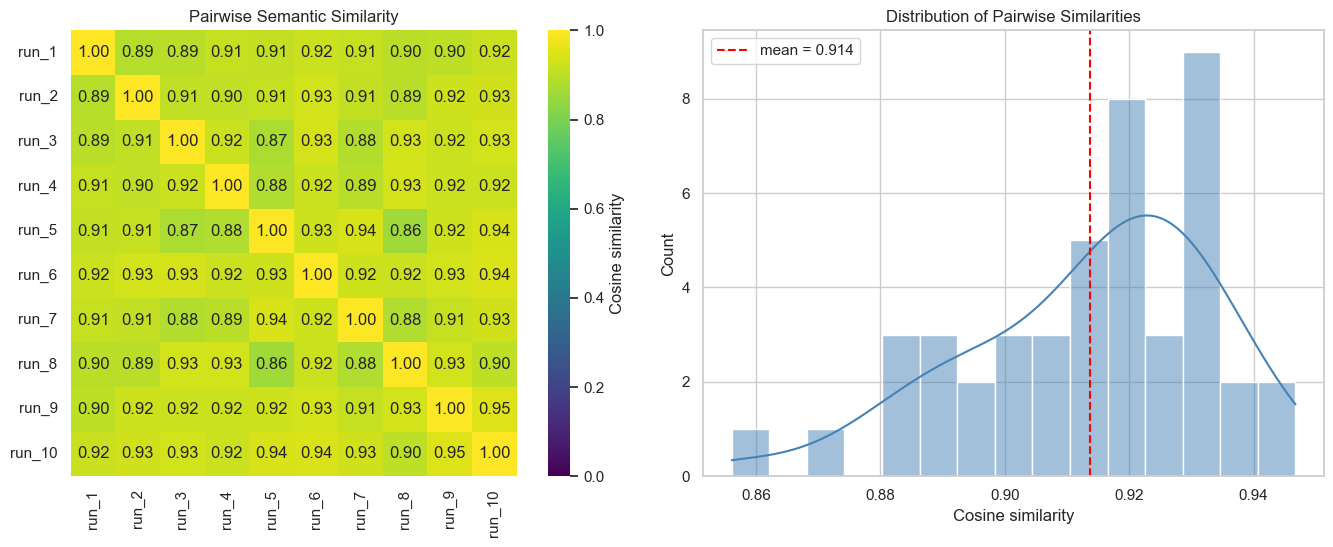

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.heatmap(sim_df, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1,
            square=True, cbar_kws={"label": "Cosine similarity"}, ax=axes[0])
axes[0].set_title("Pairwise Semantic Similarity")

sns.histplot(sim_matrix[np.triu_indices(len(df), k=1)], bins=15, kde=True, ax=axes[1], color="steelblue")
axes[1].axvline(semantic_stats["consistency_score"], color="red", linestyle="--",
                 label=f'mean = {semantic_stats["consistency_score"]:.3f}')
axes[1].set_title("Distribution of Pairwise Similarities")
axes[1].set_xlabel("Cosine similarity")
axes[1].legend()

plt.tight_layout()
plt.savefig("outputs/similarity_plots.png", dpi=150)
plt.show()

#### Final report

In [17]:
report = {
    "run_metadata": run_metadata,
    "n_successful_runs": len(df),
    "n_failed_runs": n_failed,
    "semantic_consistency": semantic_stats,
    "structural_metrics": {
        **length_stats,
        "majority_answer": majority_answer,
        "agreement_rate": agreement_rate,
        "answer_distribution": answer_counts.to_dict(),
    },
    "diversity_metrics": diversity_stats,
}

model_name = run_metadata["model"]
temp = run_metadata["temperature"]

print(" " * 60)
print(f"CONSISTENCY REPORT — {model_name} (T={temp})")
print(" " * 60)
print(f"Runs: {len(df)} successful / {N_RUNS} requested")
print(f"\nSemantic consistency score: {semantic_stats['consistency_score']:.3f}  ({verdict})")
if length_stats["mean_words"]:
    print(f"Length CV (words):          {(length_stats['std_words']/length_stats['mean_words']):.3f}")
if agreement_rate is not None:
    print(f"Final-answer agreement:     {agreement_rate:.1%}  (majority = {majority_answer})")
print(f"Unique responses:           {diversity_stats['unique_responses']}/{len(df)}")
print(f"Distinct-1 / Distinct-2:    {diversity_stats['distinct_1']:.3f} / {diversity_stats['distinct_2']:.3f}")



                                                            
CONSISTENCY REPORT — llama-3.1-8b-instant (T=0.7)
                                                            
Runs: 10 successful / 10 requested

Semantic consistency score: 0.914  (Very high consistency — outputs are essentially paraphrases of each other.)
Length CV (words):          0.169
Final-answer agreement:     50.0%  (majority = 3)
Unique responses:           10/10
Distinct-1 / Distinct-2:    0.143 / 0.427
